# $(SASA) Baseline$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [1]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Base_Line_Model
from pmbrl.data import Experiment_Data

# Training

In [2]:
data = Experiment_Data()

data.generate_episodes(10)
data.build_training_dataset()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3

,step,episode,p,s,a,r,s_,a_,r_,s__
214,14,9,"(0.08, 1.9)","[-0.017, -0.393, 0.04, 0.204]",0,1.0,"[-0.025, -0.578, 0.044, 0.283]",1.0,1.0,"[-0.037, -0.393, 0.05, 0.211]"
37,0,2,"(0.37, 0.1)","[-0.024, -0.02, 0.031, -0.041]",1,1.0,"[-0.024, 0.242, 0.031, -1.801]",1.0,1.0,"[-0.019, 0.504, -0.005, -3.564]"
164,0,7,"(0.08, 0.8)","[0.013, 0.04, 0.028, -0.027]",1,1.0,"[0.013, 0.229, 0.027, -0.202]",1.0,1.0,"[0.018, 0.419, 0.023, -0.377]"
16,16,0,"(0.31, 1.5)","[0.001, -0.378, 0.055, 0.305]",0,1.0,"[-0.006, -0.565, 0.061, 0.427]",1.0,1.0,"[-0.018, -0.379, 0.07, 0.319]"
62,5,4,"(0.96, 0.9)","[0.044, 0.198, 0.048, -0.376]",0,1.0,"[0.048, -0.004, 0.04, 0.082]",1.0,1.0,"[0.048, 0.196, 0.042, -0.336]"
...,...,...,...,...,...,...,...,...,...,...
176,12,7,"(0.08, 0.8)","[0.151, 1.56, -0.098, -1.482]",0,1.0,"[0.182, 1.371, -0.128, -1.322]",0.0,1.0,"[0.21, 1.182, -0.155, -1.168]"
169,5,7,"(0.08, 0.8)","[0.039, 0.229, 0.004, -0.187]",1,1.0,"[0.044, 0.419, 0.0, -0.367]",1.0,1.0,"[0.052, 0.609, -0.007, -0.547]"
171,7,7,"(0.08, 0.8)","[0.052, 0.609, -0.007, -0.547]",1,1.0,"[0.064, 0.799, -0.018, -0.729]",1.0,1.0,"[0.08, 0.989, -0.032, -0.912]"
85,28,4,"(0.96, 0.9)","[0.159, -0.013, -0.076, 0.273]",1,1.0,"[0.158, 0.19, -0.07, -0.195]",0.0,1.0,"[0.162, -0.01, -0.074, 0.206]"


In [3]:
model = Base_Line_Model()

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=500)
train_data = data.get_training_data(trainer, base_line=True)
train_data.head()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([237, 4])) that is different to the input size (torch.Size([4])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


,epoch,mse_s,transition,reward
0,0,"[0.01256688591092825, 0.8711293339729309, 0.01...",1.960484,0.260376
1,1,"[0.012654748745262623, 0.8572924733161926, 0.0...",1.945125,0.259989
2,2,"[0.012746782973408699, 0.8436404466629028, 0.0...",1.930017,0.259602
3,3,"[0.012842832133173943, 0.8301733732223511, 0.0...",1.915158,0.259216
4,4,"[0.012942713685333729, 0.8168909549713135, 0.0...",1.900551,0.258829


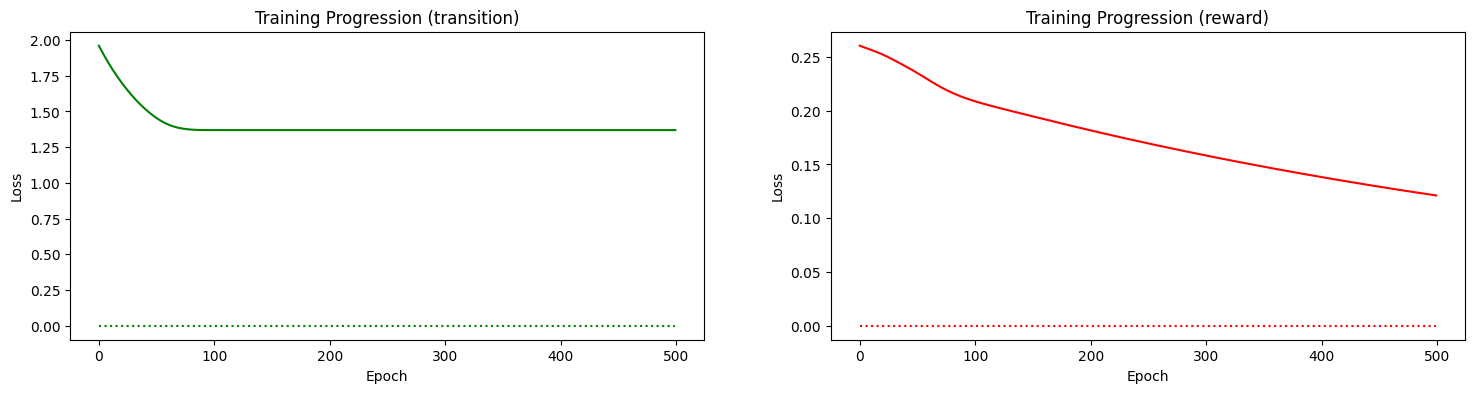

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

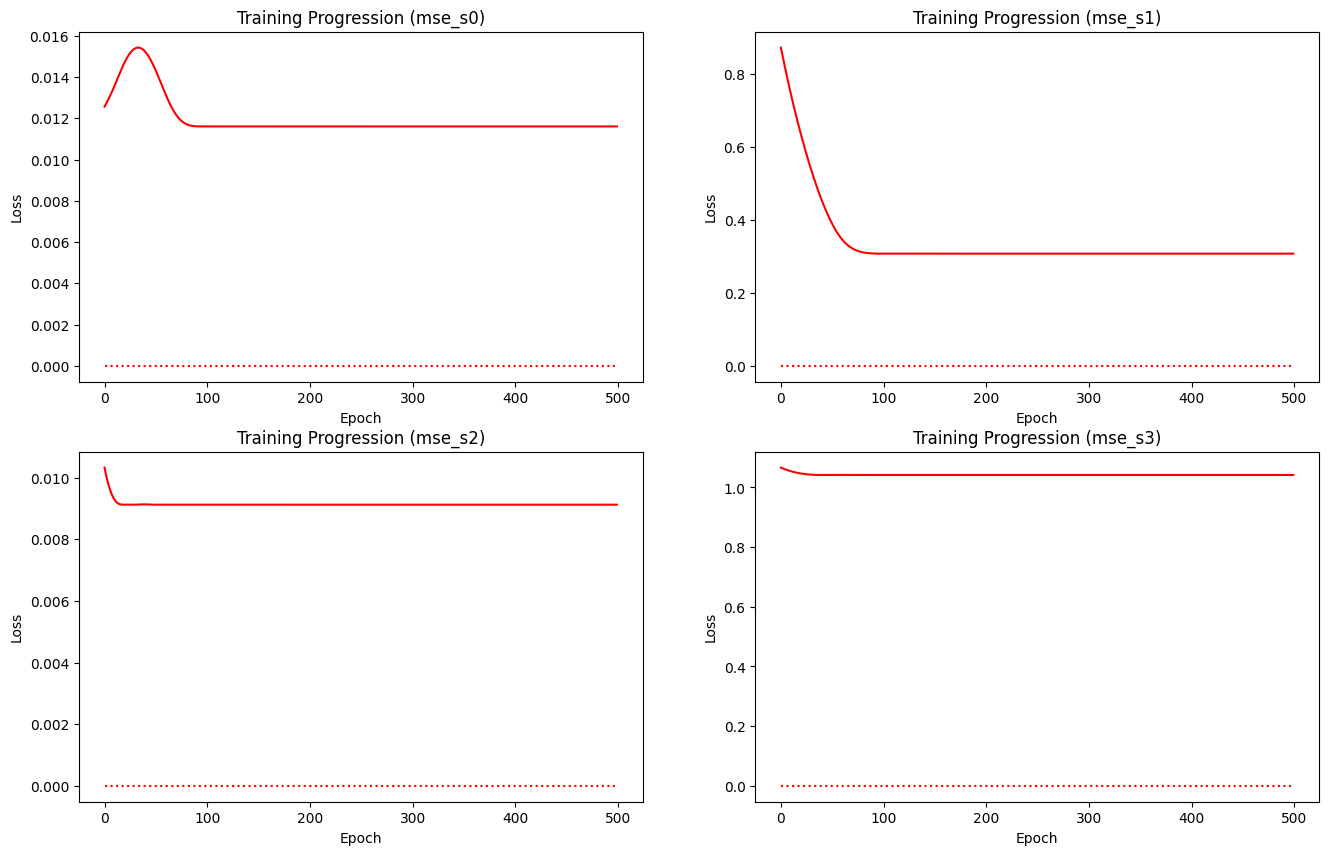

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
}

df = data.get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

# Evaluation

In [6]:
results = data.evaluate_model(model, n_episodes=10, base_line=True)
results.head()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3

,step,episode,p,s,a,r,s_,a_,r_,s__,estimated_s,estimated_r
0,0,0,"(0.65, 1.3)","[-0.047, -0.042, 0.028, -0.02]",0,1.0,"[-0.047, -0.232, 0.028, 0.174]",0.0,1.0,"[-0.052, -0.423, 0.031, 0.368]","[-0.101, -0.022, -0.056, 0.116]",0.6
1,1,0,"(0.65, 1.3)","[-0.047, -0.232, 0.028, 0.174]",0,1.0,"[-0.052, -0.423, 0.031, 0.368]",0.0,1.0,"[-0.06, -0.613, 0.039, 0.562]","[-0.025, -0.11, -0.102, 0.122]",0.6
2,2,0,"(0.65, 1.3)","[-0.052, -0.423, 0.031, 0.368]",0,1.0,"[-0.06, -0.613, 0.039, 0.562]",1.0,1.0,"[-0.073, -0.423, 0.05, 0.382]","[0.014, -0.272, -0.003, 0.168]",0.6
3,3,0,"(0.65, 1.3)","[-0.06, -0.613, 0.039, 0.562]",1,1.0,"[-0.073, -0.423, 0.05, 0.382]",1.0,1.0,"[-0.081, -0.234, 0.058, 0.205]","[-0.035, -0.151, 0.094, 0.183]",0.7
4,4,0,"(0.65, 1.3)","[-0.073, -0.423, 0.05, 0.382]",1,1.0,"[-0.081, -0.234, 0.058, 0.205]",1.0,1.0,"[-0.086, -0.044, 0.062, 0.029]","[-0.104, -0.07, 0.153, 0.186]",0.7


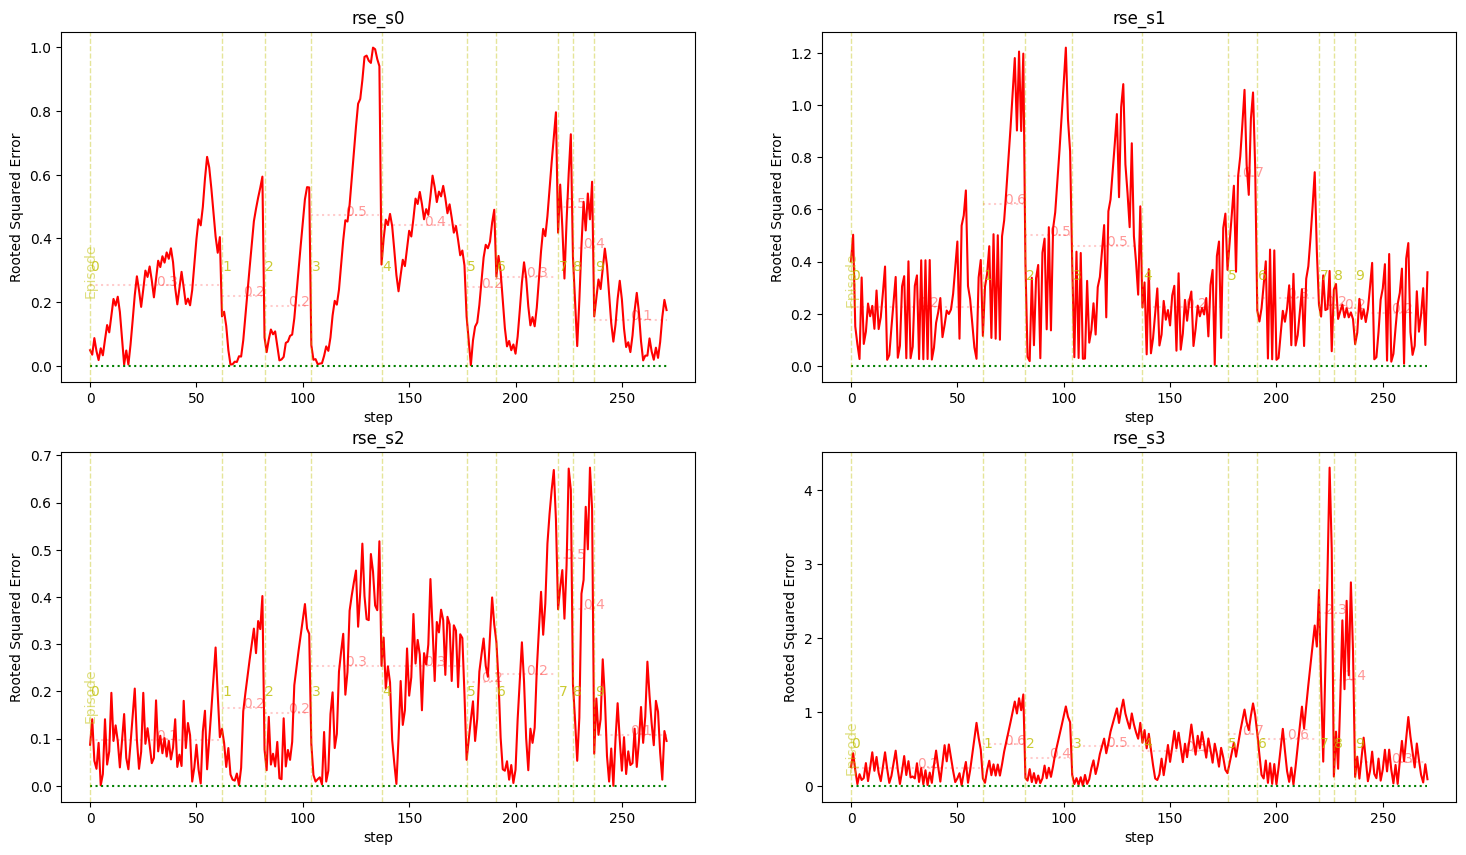

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], results, 'rse_s0')
data.plot_value_through_episodes(axs[0][1], results, 'rse_s1')
data.plot_value_through_episodes(axs[1][0], results, 'rse_s2')
data.plot_value_through_episodes(axs[1][1], results, 'rse_s3')

plt.show()

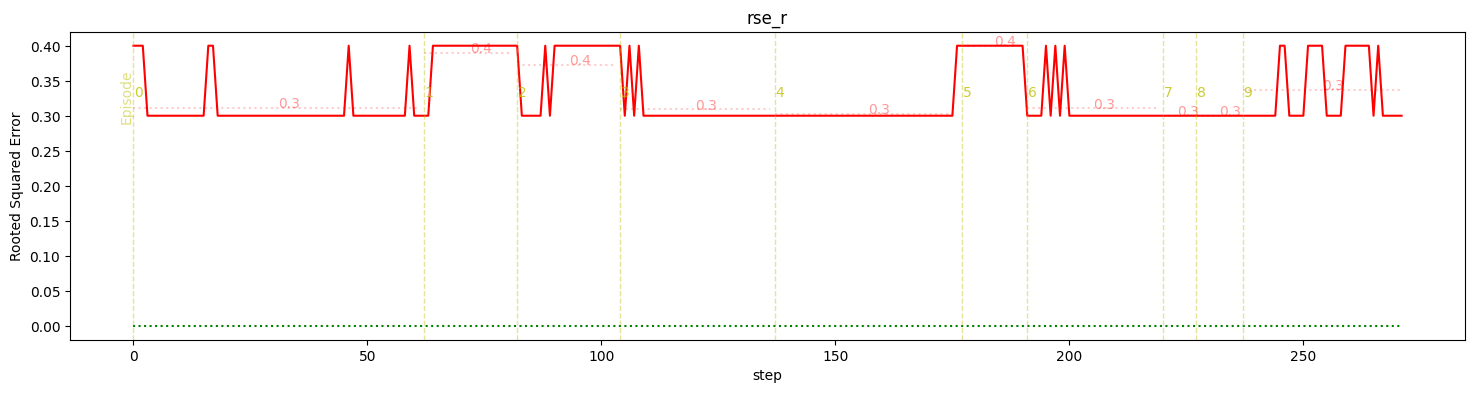

In [8]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, results, 'rse_r')
plt.show()

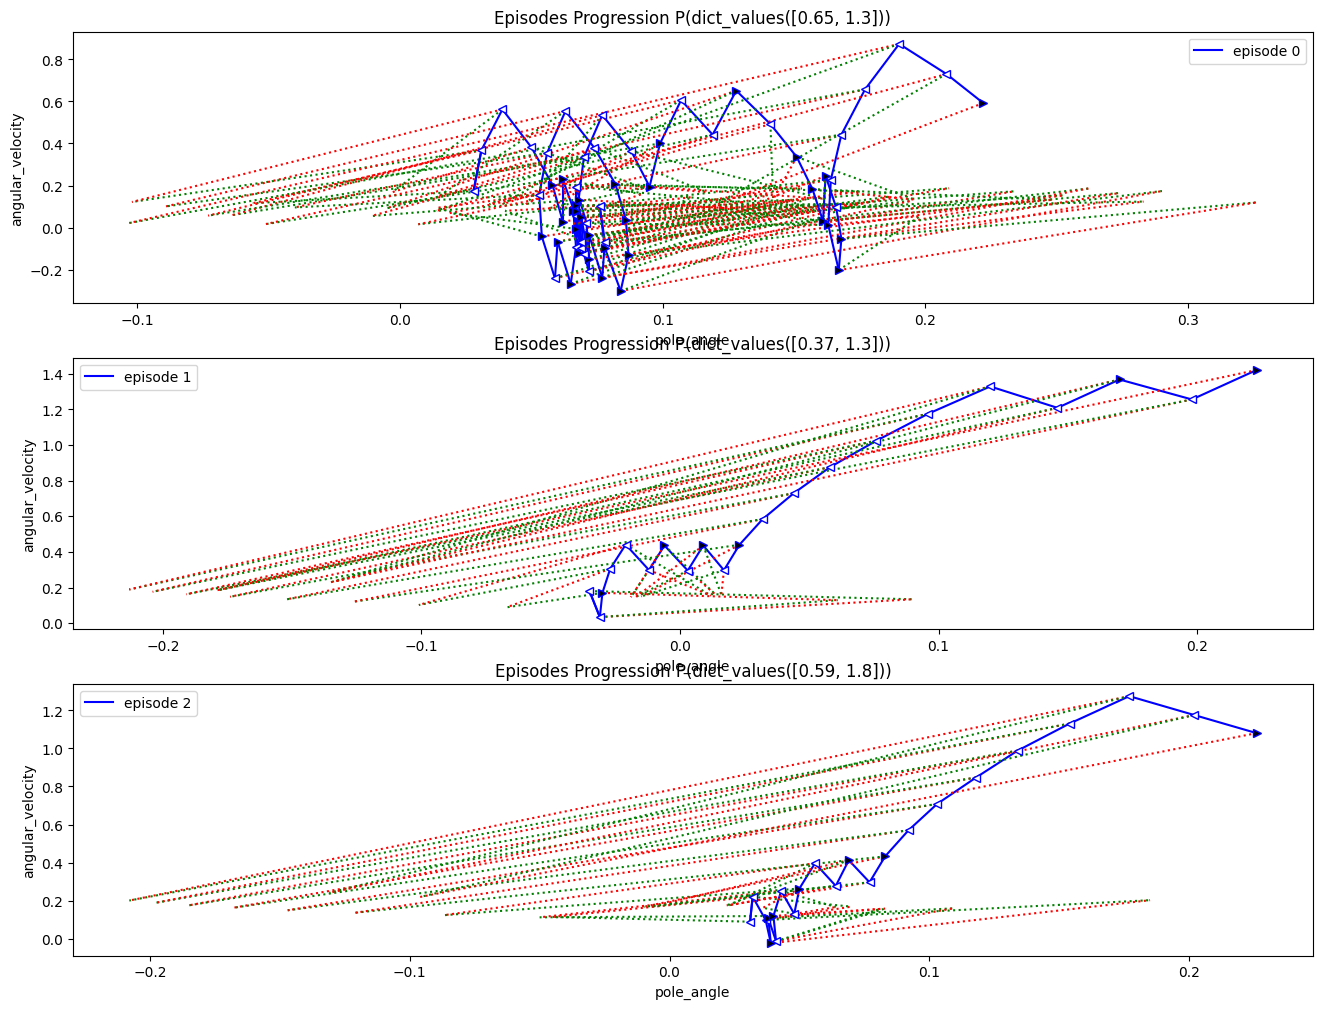

In [9]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()